In [1]:
# 🧪 ScoreProvider Log Expansion — Separated by Metric Type

import os, sys, json
import pandas as pd
from pathlib import Path

# 📁 Set up paths
PROJECT_ROOT = Path(r"C:\Repos\codecritic").resolve()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

LOG_PATH = Path("tests/backup/provider_logs.csv")
assert LOG_PATH.exists(), "❌ provider_logs.csv not found"

# 📥 Load log data
df = pd.read_csv(LOG_PATH)

# 🔍 Filter only SCORE provider logs
df_score = df[df["provider_type"] == "PROVIDER_TYPE.SCORE"].copy()

# 🧼 Safe JSON parse
def safe_json_parse(val):
    try:
        return json.loads(val) if isinstance(val, str) else {}
    except Exception:
        return {}

df_score["output_parsed"] = df_score["output"].apply(safe_json_parse)

# 🧩 Extract common ScoreOutputSchema fields
df_score["score_name"] = df_score["output_parsed"].apply(lambda x: x.get("name", "").lower())
df_score["score_value"] = df_score["output_parsed"].apply(lambda x: x.get("value"))
df_score["score_summary"] = df_score["output_parsed"].apply(lambda x: x.get("summary"))
df_score["components"] = df_score["output_parsed"].apply(lambda x: x.get("components", {}))

# 🧬 Separate by score_name
df_linting = df_score[df_score["score_name"] == "linting_score"].copy()
df_stability = df_score[df_score["score_name"] == "code_stability_score"].copy()

# 🧩 Expand LintingScoreComponents fields
if not df_linting.empty:
    df_linting["ruff_score"] = df_linting["components"].apply(lambda x: x.get("ruff_score"))
    df_linting["black_score"] = df_linting["components"].apply(lambda x: x.get("black_score"))
    df_linting["mypy_score"] = df_linting["components"].apply(lambda x: x.get("mypy_score"))
    df_linting["ruff_violations"] = df_linting["components"].apply(lambda x: x.get("ruff_violations"))
    df_linting["tool_failure_count"] = df_linting["components"].apply(lambda x: x.get("tool_failure_count"))
    df_linting["weight_ruff"] = df_linting["components"].apply(lambda x: x.get("weight_ruff"))
    df_linting["weight_black"] = df_linting["components"].apply(lambda x: x.get("weight_black"))
    df_linting["weight_mypy"] = df_linting["components"].apply(lambda x: x.get("weight_mypy"))

# 🧩 Expand CodeStabilityScoreComponents fields
if not df_stability.empty:
    df_stability["utf8_valid"] = df_stability["components"].apply(lambda x: x.get("utf8_valid"))
    df_stability["syntax_ok"] = df_stability["components"].apply(lambda x: x.get("syntax_ok"))
    df_stability["py_compile_ok"] = df_stability["components"].apply(lambda x: x.get("py_compile_ok"))
    df_stability["can_import"] = df_stability["components"].apply(lambda x: x.get("can_import"))

# 📐 Show sample
pd.set_option("display.max_colwidth", 200)

print("📊 Linting Score Logs")
display(df_linting.sort_values("timestamp").head(10))

print("\n📊 Stability Score Logs")
display(df_stability.sort_values("timestamp").head(10))


📊 Linting Score Logs


,id,session_id,timestamp,provider_id,provider_type,input,output,output_schema,latency_ms,config_hash,...,score_summary,components,ruff_score,black_score,mypy_score,ruff_violations,tool_failure_count,weight_ruff,weight_black,weight_mypy
3,4,1,2025-06-16 18:48:23.196520+00:00,1,PROVIDER_TYPE.SCORE,"{""file_path"": ""C:\\Repos\\codecritic\\working_files\\bad_indentation..__state_1348231876.py""}","{""name"": ""linting_score"", ""value"": 0.9, ""components"": {""type"": ""linting"", ""ruff_score"": 0.9, ""ruff_violations"": 1, ""black_score"": 0.9, ""mypy_score"": 0.9, ""tool_failure_count"": 0, ""weight_ruff"": 0....",ScoreOutputSchema,504,3b3085ec878f73d63ab3fd329a8756f2,...,Top Ruff violations: UNKNOWN_VIOLATION×1,"{'type': 'linting', 'ruff_score': 0.9, 'ruff_violations': 1, 'black_score': 0.9, 'mypy_score': 0.9, 'tool_failure_count': 0, 'weight_ruff': 0.7, 'weight_black': 0.2, 'weight_mypy': 0.1}",0.9,0.9,0.9,1,0,0.7,0.2,0.1
11,12,1,2025-06-16 18:48:27.331594+00:00,1,PROVIDER_TYPE.SCORE,"{""file_path"": ""C:\\Repos\\codecritic\\working_files\\temp_state_1348273315.py""}","{""name"": ""linting_score"", ""value"": 0.9, ""components"": {""type"": ""linting"", ""ruff_score"": 0.9, ""ruff_violations"": 1, ""black_score"": 0.9, ""mypy_score"": 0.9, ""tool_failure_count"": 0, ""weight_ruff"": 0....",ScoreOutputSchema,374,3b3085ec878f73d63ab3fd329a8756f2,...,Top Ruff violations: UNKNOWN_VIOLATION×1,"{'type': 'linting', 'ruff_score': 0.9, 'ruff_violations': 1, 'black_score': 0.9, 'mypy_score': 0.9, 'tool_failure_count': 0, 'weight_ruff': 0.7, 'weight_black': 0.2, 'weight_mypy': 0.1}",0.9,0.9,0.9,1,0,0.7,0.2,0.1
15,16,1,2025-06-16 18:48:27.715670+00:00,1,PROVIDER_TYPE.SCORE,"{""file_path"": ""C:\\Repos\\codecritic\\working_files\\bad_indentation..__sys_1348231802.py""}","{""name"": ""linting_score"", ""value"": 0.9, ""components"": {""type"": ""linting"", ""ruff_score"": 0.9, ""ruff_violations"": 1, ""black_score"": 0.9, ""mypy_score"": 0.9, ""tool_failure_count"": 0, ""weight_ruff"": 0....",ScoreOutputSchema,435,3b3085ec878f73d63ab3fd329a8756f2,...,Top Ruff violations: UNKNOWN_VIOLATION×1,"{'type': 'linting', 'ruff_score': 0.9, 'ruff_violations': 1, 'black_score': 0.9, 'mypy_score': 0.9, 'tool_failure_count': 0, 'weight_ruff': 0.7, 'weight_black': 0.2, 'weight_mypy': 0.1}",0.9,0.9,0.9,1,0,0.7,0.2,0.1
20,21,1,2025-06-16 18:48:28.179329+00:00,1,PROVIDER_TYPE.SCORE,"{""file_path"": ""C:\\Repos\\codecritic\\experiments\\snapshots\\1\\9697dddb-dd17-4060-8de4-995b70987d35.before""}","{""name"": ""linting_score"", ""value"": 0.9, ""components"": {""type"": ""linting"", ""ruff_score"": 0.9, ""ruff_violations"": 1, ""black_score"": 0.9, ""mypy_score"": 0.9, ""tool_failure_count"": 0, ""weight_ruff"": 0....",ScoreOutputSchema,396,3b3085ec878f73d63ab3fd329a8756f2,...,Top Ruff violations: UNKNOWN_VIOLATION×1,"{'type': 'linting', 'ruff_score': 0.9, 'ruff_violations': 1, 'black_score': 0.9, 'mypy_score': 0.9, 'tool_failure_count': 0, 'weight_ruff': 0.7, 'weight_black': 0.2, 'weight_mypy': 0.1}",0.9,0.9,0.9,1,0,0.7,0.2,0.1
24,25,1,2025-06-16 18:48:28.579917+00:00,1,PROVIDER_TYPE.SCORE,"{""file_path"": ""C:\\Repos\\codecritic\\experiments\\snapshots\\1\\9697dddb-dd17-4060-8de4-995b70987d35.after""}","{""name"": ""linting_score"", ""value"": 0.95, ""components"": {""type"": ""linting"", ""ruff_score"": 1.0, ""ruff_violations"": 0, ""black_score"": 0.9, ""mypy_score"": 0.7, ""tool_failure_count"": 0, ""weight_ruff"": 0...",ScoreOutputSchema,561,3b3085ec878f73d63ab3fd329a8756f2,...,No Ruff violations detected,"{'type': 'linting', 'ruff_score': 1.0, 'ruff_violations': 0, 'black_score': 0.9, 'mypy_score': 0.7, 'tool_failure_count': 0, 'weight_ruff': 0.7, 'weight_black': 0.2, 'weight_mypy': 0.1}",1.0,0.9,0.7,0,0,0.7,0.2,0.1
29,30,1,2025-06-16 18:48:29.167480+00:00,1,PROVIDER_TYPE.SCORE,"{""file_path"": ""C:\\Repos\\codecritic\\working_files\\temp_state_1348291674.py""}","{""name"": ""linting_score"", ""value"": 0.95, ""components"": {""type"": ""linting"", 


📊 Stability Score Logs


,id,session_id,timestamp,provider_id,provider_type,input,output,output_schema,latency_ms,config_hash,...,execution_chain,output_parsed,score_name,score_value,score_summary,components,utf8_valid,syntax_ok,py_compile_ok,can_import
35,36,1,2025-06-16 18:48:30.472286+00:00,2,PROVIDER_TYPE.SCORE,"{""file_path"": ""C:\\Repos\\codecritic\\working_files\\temp_state_1348304524__state_1348304682.py"", ""session_id"": 1, ""reason"": ""evaluating"", ""steps"": 6, ""retry_count"": 0, ""_last_state"": ""start"", ""de...","{""name"": ""code_stability_score"", ""value"": 1.0, ""components"": {""type"": ""code_stability"", ""utf8_valid"": 1.0, ""syntax_ok"": 1.0, ""py_compile_ok"": 1.0, ""can_import"": 1.0}, ""summary"": ""\u2705 Executable""}",ScoreOutputSchema,3,ea02debd28fe7cacc8a6a2991bd5705d,...,"['5639f147-aecc-491a-b0cc-e50e2ea630f8', '8fdffe3c-f267-4c70-ac15-662a06794d3b', 'e3f82853-c00b-4295-804b-bc4074214a1a', '46fabec4-c5d6-4e54-b785-9d5494cbfe8d', '831b16d8-6ad9-459f-a21a-255827f2ec...","{'name': 'code_stability_score', 'value': 1.0, 'components': {'type': 'code_stability', 'utf8_valid': 1.0, 'syntax_ok': 1.0, 'py_compile_ok': 1.0, 'can_import': 1.0}, 'summary': '✅ Executable'}",code_stability_score,1.0,✅ Executable,"{'type': 'code_stability', 'utf8_valid': 1.0, 'syntax_ok': 1.0, 'py_compile_ok': 1.0, 'can_import': 1.0}",1.0,1.0,1.0,1.0
108,109,1,2025-06-16 18:48:44.973407+00:00,2,PROVIDER_TYPE.SCORE,"{""file_path"": ""C:\\Repos\\codecritic\\working_files\\temp_state_1348449512__state_1348449691.py"", ""session_id"": 1, ""reason"": ""evaluating"", ""steps"": 6, ""retry_count"": 0, ""_last_state"": ""start"", ""de...","{""name"": ""code_stability_score"", ""value"": 1.0, ""components"": {""type"": ""code_stability"", ""utf8_valid"": 1.0, ""syntax_ok"": 1.0, ""py_compile_ok"": 1.0, ""can_import"": 1.0}, ""summary"": ""\u2705 Executable""}",ScoreOutputSchema,3,ea02debd28fe7cacc8a6a2991bd5705d,...,"['5be030ce-725e-4f24-aa82-820c1379025c', '94d564fd-0606-4ead-9595-67bace6d398c', 'bf62fd2c-06bf-4f8a-87b7-7027505eaf8c', '1b81c4da-28a1-4757-b29a-f6058cf96e91', 'fe55aa17-f627-4618-9f6e-52265b5136...","{'name': 'code_stability_score', 'value': 1.0, 'components': {'type': 'code_stability', 'utf8_valid': 1.0, 'syntax_ok': 1.0, 'py_compile_ok': 1.0, 'can_import': 1.0}, 'summary': '✅ Executable'}",code_stability_score,1.0,✅ Executable,"{'type': 'code_stability', 'utf8_valid': 1.0, 'syntax_ok': 1.0, 'py_compile_ok': 1.0, 'can_import': 1.0}",1.0,1.0,1.0,1.0
181,182,1,2025-06-16 18:48:58.931444+00:00,2,PROVIDER_TYPE.SCORE,"{""file_path"": ""C:\\Repos\\codecritic\\working_files\\temp_state_1348589159__state_1348589211.py"", ""session_id"": 1, ""reason"": ""evaluating"", ""steps"": 6, ""retry_count"": 0, ""_last_state"": ""start"", ""de...","{""name"": ""code_stability_score"", ""value"": 1.0, ""components"": {""type"": ""code_stability"", ""utf8_valid"": 1.0, ""syntax_ok"": 1.0, ""py_compile_ok"": 1.0, ""can_import"": 1.0}, ""summary"": ""\u2705 Executable""}",ScoreOutputSchema,3,ea02debd28fe7cacc8a6a2991bd5705d,...,"['01c9d1ff-96ec-4614-b30d-04fc6cdc7a2e', 'df61626e-6d78-4bc7-bb48-14ab7c2d1c93', 'c250efe9-af85-42fe-a8d0-32ae4ed7d547', 'b1e9ef2a-a582-4883-9dac-aec1681e9a4a', 'dc029ea6-72fb-4237-9258-7241c4a8be...","{'name': 'code_stability_score', 'value': 1.0, 'components': {'type': 'code_stability', 'utf8_valid': 1.0, 'syntax_ok': 1.0, 'py_compile_ok': 1.0, 'can_import': 1.0}, 'summary': '✅ Executable'}",code_stability_score,1.0,✅ Executable,"{'type': 'code_stability', 'utf8_valid': 1.0, 'syntax_ok': 1.0, 'py_compile_ok': 1.0, 'can_import': 1.0}",1.0,1.0,1.0,1.0
254,255,1,2025-06-16 18:49:13.526384+00:00,2,PROVIDER_TYPE.SCORE,"{""file_path"": ""C:\\Repos\\codecritic\\working_files\\temp_state_1349135053__state_1349135092.py"", ""session_id"": 1, ""reason"": ""evaluating"", ""steps"": 6, ""retry_count"": 0, ""_last_state"": ""start"", ""de...","{""name"": ""code_stability_score"", ""value"": 1.0, ""components"": {""type"": ""code_stability"", ""utf

c:\Repos\codecritic\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129529 (\N{BROOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


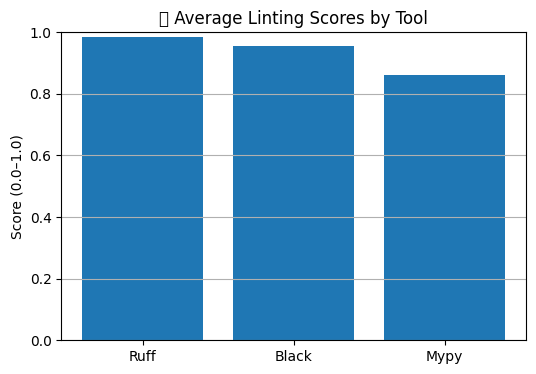

In [2]:
import matplotlib.pyplot as plt

# 🎯 Average score by tool type
tool_scores = {
    "Ruff": df_linting["ruff_score"].mean(),
    "Black": df_linting["black_score"].mean(),
    "Mypy": df_linting["mypy_score"].mean()
}

plt.figure(figsize=(6, 4))
plt.bar(tool_scores.keys(), tool_scores.values())
plt.title("🧹 Average Linting Scores by Tool")
plt.ylabel("Score (0.0–1.0)")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()


c:\Repos\codecritic\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


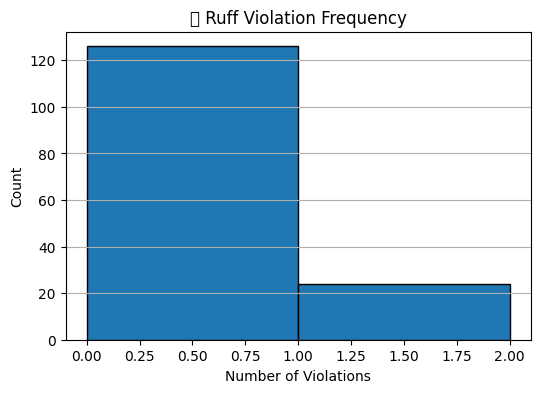

In [3]:
plt.figure(figsize=(6, 4))
plt.hist(df_linting["ruff_violations"], bins=range(0, df_linting["ruff_violations"].max()+2), edgecolor='black')
plt.title("🐍 Ruff Violation Frequency")
plt.xlabel("Number of Violations")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()


c:\Repos\codecritic\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


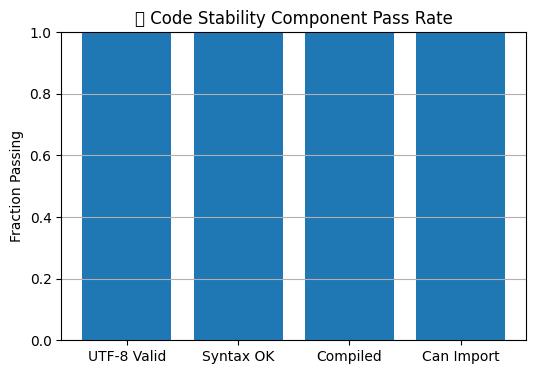

In [4]:
# 🔢 Compute pass rate for each stability check
stability_checks = {
    "UTF-8 Valid": df_stability["utf8_valid"].mean(),
    "Syntax OK": df_stability["syntax_ok"].mean(),
    "Compiled": df_stability["py_compile_ok"].mean(),
    "Can Import": df_stability["can_import"].mean(),
}

plt.figure(figsize=(6, 4))
plt.bar(stability_checks.keys(), stability_checks.values())
plt.title("🛡️ Code Stability Component Pass Rate")
plt.ylabel("Fraction Passing")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()


C:\Users\ben\AppData\Local\Temp\ipykernel_89572\2444900999.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(
c:\Repos\codecritic\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


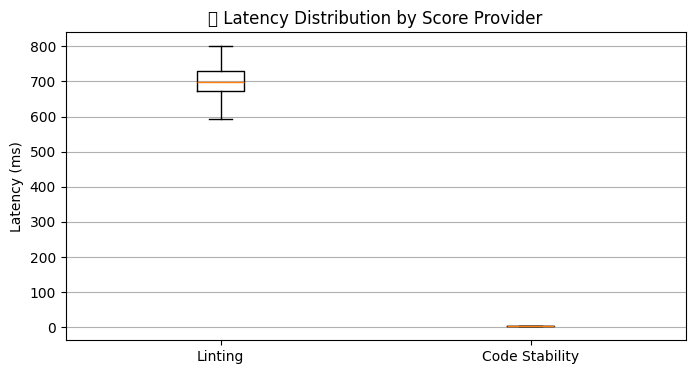

In [5]:
plt.figure(figsize=(8, 4))
plt.boxplot(
    [df_linting["latency_ms"], df_stability["latency_ms"]],
    labels=["Linting", "Code Stability"],
    showfliers=False
)
plt.title("⏱️ Latency Distribution by Score Provider")
plt.ylabel("Latency (ms)")
plt.grid(axis='y')
plt.show()
